# Análisis exploratorio, estadística descriptiva y visualización de patrones

Este notebook desarrolla tres componentes fundamentales de la analítica de datos:

1. **Análisis exploratorio de datos**
2. **Estadística descriptiva**
3. **Visualización e identificación de patrones**

El propósito no es aprender únicamente instrucciones de Python. Se busca comprender:

- qué pregunta responde cada procedimiento;
- cuál es su fundamento matemático;
- cómo interpretar sus resultados;
- qué gráfico conviene utilizar;
- qué errores deben evitarse;
- cómo comunicar hallazgos sustentados en evidencia.

---

## Librerías utilizadas

- **NumPy:** cálculo numérico.
- **Pandas:** manipulación y resumen de datos.
- **Matplotlib:** construcción de gráficos.
- **Seaborn:** visualización estadística.

---

## Objetivos

- identificar la unidad de observación;
- clasificar variables cualitativas y cuantitativas;
- inspeccionar la estructura de una base;
- evaluar valores faltantes, duplicados e inconsistencias;
- construir distribuciones de frecuencia;
- calcular e interpretar medidas de tendencia central;
- calcular e interpretar medidas de posición y dispersión;
- describir la forma de una distribución;
- detectar valores potencialmente atípicos;
- analizar covarianza y correlación;
- seleccionar gráficos apropiados;
- reconocer patrones univariados, bivariados y multivariados;
- formular conclusiones prudentes y útiles.

# Contenido

## Parte I. Análisis exploratorio de datos

1. Concepto y propósito del EDA  
2. Unidad de observación y tipos de variables  
3. Inspección estructural  
4. Calidad de los datos  
5. Limpieza inicial  

## Parte II. Estadística descriptiva

6. Distribuciones de frecuencia  
7. Medidas de tendencia central  
8. Medidas de posición  
9. Medidas de dispersión  
10. Forma de la distribución  
11. Valores atípicos  
12. Covarianza y correlación  

## Parte III. Visualización de patrones

13. Principios de visualización  
14. Análisis univariado  
15. Análisis bivariado  
16. Análisis multivariado  
17. Patrones por grupos  
18. Transformaciones  

## Parte IV. Aplicación y ejercicios

19. Caso de clientes  
20. Ejercicios por sección  
21. Reto final  
22. Soluciones orientativas

# 1. Preparación del entorno

Importamos las librerías necesarias.

La instrucción:

```python
sns.set_theme(style="whitegrid")
```

aplica un estilo que facilita la lectura de escalas y comparaciones.

In [2]:
%mamba install numpy pandas matplotlib seaborn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.392 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ patsy          1.0.2    py313h1804a44_3      emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.1.2   pyh145f28c_0         conda-forge


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Entorno preparado correctamente.")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Seaborn:", sns.__version__)

Entorno preparado correctamente.
NumPy: 2.5.0
Pandas: 3.0.5
Seaborn: 0.13.2


# 2. Base de datos de trabajo

Se construirá una base ficticia de clientes de una empresa comercial.

Cada fila representa **un cliente** y cada columna representa una característica.

La base incluirá variables demográficas, económicas y de comportamiento.

In [4]:
n = 500

clientes = pd.DataFrame({
    "cliente_id": np.arange(1001, 1001 + n),
    "edad": np.random.normal(loc=38, scale=12, size=n).round(),
    "genero": np.random.choice(
        ["Femenino", "Masculino", "Otro"],
        size=n,
        p=[0.49, 0.48, 0.03]
    ),
    "region": np.random.choice(
        ["Norte", "Centro", "Sur", "Oriente"],
        size=n,
        p=[0.24, 0.36, 0.25, 0.15]
    ),
    "segmento": np.random.choice(
        ["Básico", "Intermedio", "Premium"],
        size=n,
        p=[0.45, 0.35, 0.20]
    ),
    "ingreso_mensual": np.random.lognormal(
        mean=np.log(2800),
        sigma=0.48,
        size=n
    ),
    "visitas_mes": np.random.poisson(lam=5, size=n),
    "satisfaccion": np.random.normal(
        loc=4.0,
        scale=0.65,
        size=n
    ).clip(1, 5)
})

ajuste_segmento = clientes["segmento"].map({
    "Básico": 0,
    "Intermedio": 300,
    "Premium": 850
})

clientes["gasto_mensual"] = (
    0.22 * clientes["ingreso_mensual"]
    + 95 * clientes["visitas_mes"]
    + ajuste_segmento
    + np.random.normal(0, 280, n)
).clip(50)

clientes["compras_ultimo_anio"] = (
    2.2 * clientes["visitas_mes"]
    + np.random.poisson(lam=5, size=n)
).round()

prob_abandono = (
    0.06
    + 0.22 * (clientes["satisfaccion"] < 3.5)
    + 0.10 * (clientes["visitas_mes"] <= 2)
    + 0.05 * (clientes["segmento"] == "Básico")
)

clientes["abandono"] = np.where(
    np.random.rand(n) < prob_abandono,
    "Sí",
    "No"
)

clientes["ingreso_mensual"] = clientes["ingreso_mensual"].round(2)
clientes["gasto_mensual"] = clientes["gasto_mensual"].round(2)
clientes["satisfaccion"] = clientes["satisfaccion"].round(1)
clientes["compras_ultimo_anio"] = clientes["compras_ultimo_anio"].astype(int)

clientes.head()

,cliente_id,edad,genero,region,segmento,ingreso_mensual,visitas_mes,satisfaccion,gasto_mensual,compras_ultimo_anio,abandono
0,1001,44.00,Masculino,Oriente,Básico,"6,079.97",1,3.90,"1,436.51",6,No
1,1002,36.00,Masculino,Norte,Básico,"2,398.65",5,3.80,649.33,17,No
2,1003,46.00,Femenino,Sur,Intermedio,"5,022.14",4,4.20,"1,922.37",15,No
3,1004,56.00,Otro,Norte,Intermedio,"5,811.57",3,4.50,"2,140.37",10,No
4,1005,35.00,Masculino,Centro,Premium,"4,521.34",3,3.40,"2,272.07",14,Sí


## Construcción de la base ficticia

La base contiene **500 clientes simulados**. Las variables se generaron de la siguiente manera:

* `cliente_id`: secuencia de identificadores desde 1001.
* `edad`: distribución normal con media 38 y desviación estándar 12:

$$
\text{Edad}\sim N(38,12^2).
$$

* `genero`, `region` y `segmento`: variables categóricas generadas con probabilidades previamente definidas.
* `ingreso_mensual`: distribución lognormal, adecuada para representar ingresos positivos y asimétricos:

$$
\log(\text{Ingreso})\sim N(\log(2800),0.48^2).
$$

* `visitas_mes`: distribución de Poisson con promedio de 5 visitas:

$$
\text{Visitas}\sim \operatorname{Poisson}(5).
$$

* `satisfaccion`: distribución normal con media 4 y desviación estándar 0.65, limitada al intervalo de 1 a 5.
* `gasto_mensual`: combinación del ingreso, las visitas, el segmento comercial y un error aleatorio normal:

$$
\text{Gasto} \sim
0.22(\text{Ingreso})
+
95(\text{Visitas})
+
\text{Ajuste del segmento}
+
\varepsilon,
$$

donde:

$$
\varepsilon\sim N(0,280^2).
$$

* `compras_ultimo_anio`: depende del número de visitas más una variación aleatoria de Poisson.
* `abandono`: variable binaria simulada con una probabilidad mayor para clientes con baja satisfacción, pocas visitas o segmento Básico.

Finalmente, las variables monetarias y de satisfacción se redondearon. Esta es una **base sintética**, creada únicamente con fines académicos.


In [8]:
clientes.to_csv("clientes.csv", index = False)

## 2.1 Incorporación intencional de problemas de calidad

En bases reales es común encontrar:

- valores faltantes;
- filas duplicadas;
- valores imposibles;
- observaciones extremas;
- categorías inconsistentes.

Se incorporarán algunos problemas para practicar su detección.

In [13]:
# Valores faltantes
clientes.loc[[7, 29, 85, 141, 320], "ingreso_mensual"] = np.nan
clientes.loc[[12, 44, 173, 402], "satisfaccion"] = np.nan
clientes.loc[[31, 112, 277], "region"] = np.nan

# Valores atípicos
clientes.loc[5, "edad"] = 120
clientes.loc[18, "gasto_mensual"] = 18_000
clientes.loc[55, "visitas_mes"] = 35
clientes.loc[90, "ingreso_mensual"] = 25_000

# Duplicados
clientes = pd.concat(
    [clientes, clientes.iloc[[10, 25]]],
    ignore_index=True
)

clientes.tail()

,cliente_id,edad,genero,region,segmento,ingreso_mensual,visitas_mes,satisfaccion,gasto_mensual,compras_ultimo_anio,abandono
499,1500,21.00,Masculino,Centro,Básico,"3,011.58",8,4.70,"1,786.81",25,No
500,1011,32.00,Femenino,Norte,Básico,"1,589.91",6,4.50,847.77,17,Sí
501,1026,39.00,Masculino,Oriente,Premium,"3,052.07",4,3.40,"2,134.31",14,Sí
502,1011,32.00,Femenino,Norte,Básico,"1,589.91",6,4.50,847.77,17,Sí
503,1026,39.00,Masculino,Oriente,Premium,"3,052.07",4,3.40,"2,134.31",14,Sí


In [14]:
clientes.to_csv("clientes1.csv", index = False)

## 2.2 Diccionario de variables

| Variable | Descripción | Tipo conceptual |
|---|---|---|
| `cliente_id` | Identificador único | Identificador |
| `edad` | Edad del cliente | Cuantitativa discreta |
| `genero` | Género reportado | Cualitativa nominal |
| `region` | Región de residencia | Cualitativa nominal |
| `segmento` | Nivel comercial | Cualitativa ordinal |
| `ingreso_mensual` | Ingreso mensual estimado | Cuantitativa continua |
| `gasto_mensual` | Gasto mensual en la empresa | Cuantitativa continua |
| `visitas_mes` | Número de visitas mensuales | Cuantitativa discreta |
| `satisfaccion` | Calificación de satisfacción | Cuantitativa ordinal |
| `compras_ultimo_anio` | Número de compras en un año | Cuantitativa discreta |
| `abandono` | Indica si el cliente abandonó | Cualitativa binaria |

# PARTE I. ANÁLISIS EXPLORATORIO DE DATOS

# 3. ¿Qué es el análisis exploratorio de datos?

El **Análisis Exploratorio de Datos**, abreviado como EDA, reúne procedimientos para comprender una base antes de aplicar modelos estadísticos o algoritmos predictivos.

El EDA busca responder preguntas como:

- ¿qué representa cada observación?;
- ¿qué variables existen?;
- ¿qué tipo de información contienen?;
- ¿hay errores o valores ausentes?;
- ¿cómo se distribuyen los datos?;
- ¿qué observaciones son inusuales?;
- ¿qué relaciones parecen existir?;
- ¿qué patrones requieren investigación?

Puede sintetizarse como:

$$
\text{EDA}
=
\text{comprensión}
+
\text{calidad}
+
\text{resumen}
+
\text{visualización}
+
\text{interpretación}.
$$

El EDA es principalmente una etapa de **descubrimiento**. No reemplaza la inferencia estadística ni demuestra causalidad.

## 3.1 Unidad de observación

La **unidad de observación** es el objeto representado por cada fila.

En esta base:

$$
\text{una fila}=\text{un cliente}.
$$

Este concepto determina la interpretación de las variables.

Por ejemplo, `gasto_mensual` corresponde al gasto de un cliente y no al gasto total de una región.

## 3.2 Población y muestra

Sea una población de tamaño \(N\):

$$
\mathcal{P}=\{1,2,\ldots,N\}.
$$

Una muestra de tamaño \(n\) es un subconjunto:

$$
s\subseteq \mathcal{P},
\qquad |s|=n.
$$

La estadística descriptiva resume directamente los datos observados. Generalizar a una población requiere información sobre el diseño de muestreo o un modelo.

## 3.3 Tipos de variables

### Cualitativas

Representan categorías.

- **Nominales:** no poseen un orden natural.
- **Ordinales:** sus categorías pueden ordenarse.

### Cuantitativas

Representan cantidades.

- **Discretas:** suelen provenir de conteos.
- **Continuas:** pueden tomar valores en un intervalo.

### Identificadores

Distinguen observaciones, pero no deben analizarse como magnitudes.

# 4. Inspección estructural

## 4.1 Primeras observaciones

In [15]:
clientes.head()

,cliente_id,edad,genero,region,segmento,ingreso_mensual,visitas_mes,satisfaccion,gasto_mensual,compras_ultimo_anio,abandono
0,1001,44.00,Masculino,Oriente,Básico,"6,079.97",1,3.90,"1,436.51",6,No
1,1002,36.00,Masculino,Norte,Básico,"2,398.65",5,3.80,649.33,17,No
2,1003,46.00,Femenino,Sur,Intermedio,"5,022.14",4,4.20,"1,922.37",15,No
3,1004,56.00,Otro,Norte,Intermedio,"5,811.57",3,4.50,"2,140.37",10,No
4,1005,35.00,Masculino,Centro,Premium,"4,521.34",3,3.40,"2,272.07",14,Sí


## 4.2 Últimas observaciones

In [16]:
clientes.tail()

,cliente_id,edad,genero,region,segmento,ingreso_mensual,visitas_mes,satisfaccion,gasto_mensual,compras_ultimo_anio,abandono
499,1500,21.00,Masculino,Centro,Básico,"3,011.58",8,4.70,"1,786.81",25,No
500,1011,32.00,Femenino,Norte,Básico,"1,589.91",6,4.50,847.77,17,Sí
501,1026,39.00,Masculino,Oriente,Premium,"3,052.07",4,3.40,"2,134.31",14,Sí
502,1011,32.00,Femenino,Norte,Básico,"1,589.91",6,4.50,847.77,17,Sí
503,1026,39.00,Masculino,Oriente,Premium,"3,052.07",4,3.40,"2,134.31",14,Sí


## 4.3 Dimensiones

La propiedad `shape` devuelve:

$$
(\text{número de filas},\text{número de columnas}).
$$

In [24]:
clientes.shape

(504, 11)

## 4.4 Nombres de las variables

In [18]:
clientes.columns.tolist()

['cliente_id',
 'edad',
 'genero',
 'region',
 'segmento',
 'ingreso_mensual',
 'visitas_mes',
 'satisfaccion',
 'gasto_mensual',
 'compras_ultimo_anio',
 'abandono']

## 4.5 Tipos computacionales

In [19]:
clientes.dtypes

cliente_id               int32
edad                   float64
genero                     str
region                     str
segmento                   str
ingreso_mensual        float64
visitas_mes              int32
satisfaccion           float64
gasto_mensual          float64
compras_ultimo_anio      int32
abandono                   str
dtype: object

Los tipos computacionales no siempre coinciden con los tipos estadísticos.

Por ejemplo:

- `cliente_id` está almacenado como entero, pero es un identificador;
- `satisfaccion` está almacenada como número, aunque tiene carácter ordinal;
- `segmento` está almacenado como texto, pero posee un orden conceptual.

## 4.6 Información general

In [20]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cliente_id           504 non-null    int32  
 1   edad                 504 non-null    float64
 2   genero               504 non-null    str    
 3   region               501 non-null    str    
 4   segmento             504 non-null    str    
 5   ingreso_mensual      499 non-null    float64
 6   visitas_mes          504 non-null    int32  
 7   satisfaccion         500 non-null    float64
 8   gasto_mensual        504 non-null    float64
 9   compras_ultimo_anio  504 non-null    int32  
 10  abandono             504 non-null    str    
dtypes: float64(4), int32(3), str(4)
memory usage: 29.6 KB


## 4.7 Valores distintos por variable

In [21]:
clientes.nunique()

cliente_id             500
edad                    61
genero                   3
region                   4
segmento                 3
ingreso_mensual        495
visitas_mes             14
satisfaccion            31
gasto_mensual          500
compras_ultimo_anio     29
abandono                 2
dtype: int64

## 4.8 Selección con `loc`

In [25]:
clientes.loc[
    50:55,
    ["cliente_id", "edad", "region", "ingreso_mensual"]
]

,cliente_id,edad,region,ingreso_mensual
50,1051,42.00,Centro,"1,787.13"
51,1052,33.00,Oriente,"4,715.67"
52,1053,30.00,Centro,"2,164.86"
53,1054,45.00,Centro,"4,126.74"
54,1055,50.00,Norte,"3,339.82"
55,1056,49.00,Sur,"6,766.25"


## 4.9 Selección con `iloc`

In [31]:
# [Filas, Columnas]

clientes.iloc[
    22:29 ,
    1:5 
]

,edad,genero,region,segmento
22,39.00,Masculino,Oriente,Básico
23,21.00,Femenino,Centro,Premium
24,31.00,Femenino,Sur,Intermedio
25,39.00,Masculino,Oriente,Premium
26,24.00,Masculino,Norte,Básico
27,43.00,Masculino,Oriente,Premium
28,31.00,Masculino,Sur,Premium


# 5. Calidad de los datos

La calidad puede evaluarse mediante:

- **completitud:** presencia de valores;
- **unicidad:** ausencia de duplicados;
- **validez:** cumplimiento de reglas;
- **consistencia:** coherencia entre variables;
- **precisión:** cercanía al valor real;
- **oportunidad:** actualidad de la información.

## 5.1 Valores faltantes

Sea $m_j$ el número de valores faltantes de la variable $j$.

La proporción de faltantes es:

$$
p_j=\frac{m_j}{n}.
$$

En porcentaje:

$$
p_j(\%)=\frac{m_j}{n}\times 100.
$$

In [50]:
# isna() revisa cada celda del DataFrame y devuelve: True si el valor es nulo (NaN), False si el valor existe
# sum() cuenta los valores nulos por columna.
# .to_frame() la Serie se convierte en un DataFrame

faltantes = clientes.isna().sum().to_frame("cantidad")
faltantes["porcentaje"] = (
    (faltantes["cantidad"] / len(clientes)) * 100
).round(2)

faltantes

,cantidad,porcentaje
cliente_id,0,0.00
edad,0,0.00
genero,0,0.00
region,3,0.60
segmento,0,0.00
ingreso_mensual,5,0.99
visitas_mes,0,0.00
satisfaccion,4,0.79
gasto_mensual,0,0.00
compras_ultimo_anio,0,0.00


In [39]:
clientes.isna().sum()

cliente_id             0
edad                   0
genero                 0
region                 3
segmento               0
ingreso_mensual        5
visitas_mes            0
satisfaccion           4
gasto_mensual          0
compras_ultimo_anio    0
abandono               0
dtype: int64

In [40]:
len(clientes)

504

### Gráfico de valores faltantes

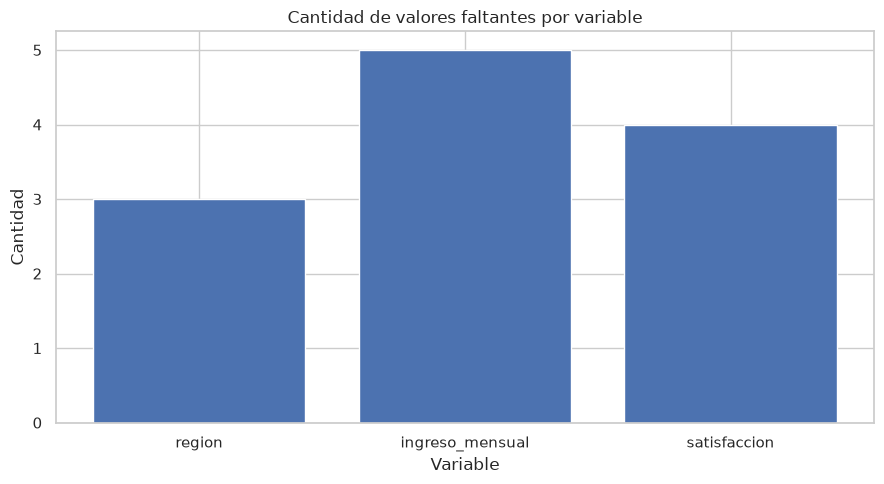

In [52]:
faltantes_con_valores = faltantes[faltantes["cantidad"] > 0]

plt.figure(figsize=(9, 5))
plt.bar(
    faltantes_con_valores.index,
    faltantes_con_valores["cantidad"]
)
plt.title("Cantidad de valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Mecanismos de ausencia

Conceptualmente, los faltantes pueden clasificarse como:

- **MCAR:** ausencia completamente aleatoria: por ejemplo, un computador donde se almacenaban las respuestas sufrió un fallo y se perdieron aleatoriamente algunos ingresos.
- **MAR:** ausencia relacionada con variables observadas: por ejemplo, los hombres mayores de 50 años responden menos la pregunta sobre ingresos (depende del ingreso?).
- **MNAR:** ausencia relacionada con el valor no observado: por ejemplo, Muchas personas con ingresos muy altos prefieren no responder (de qué depende?).

La imputación no debe elegirse únicamente por conveniencia.

## 5.2 Registros duplicados

In [58]:
# La función duplicated() revisa cada fila del DataFrame y responde a la pregunta: ¿Esta fila es un duplicado de una fila anterior?

clientes.duplicated()
print(clientes.duplicated().sum())

4


In [64]:
# keep=False Muestra todas las filas que pertenecen a un grupo duplicado, incluyendo la primera aparición.
clientes[
    clientes.duplicated(keep=False)
]

,cliente_id,edad,genero,region,segmento,ingreso_mensual,visitas_mes,satisfaccion,gasto_mensual,compras_ultimo_anio,abandono
10,1011,32.00,Femenino,Norte,Básico,"1,589.91",6,4.50,847.77,17,Sí
25,1026,39.00,Masculino,Oriente,Premium,"3,052.07",4,3.40,"2,134.31",14,Sí
500,1011,32.00,Femenino,Norte,Básico,"1,589.91",6,4.50,847.77,17,Sí
501,1026,39.00,Masculino,Oriente,Premium,"3,052.07",4,3.40,"2,134.31",14,Sí
502,1011,32.00,Femenino,Norte,Básico,"1,589.91",6,4.50,847.77,17,Sí
503,1026,39.00,Masculino,Oriente,Premium,"3,052.07",4,3.40,"2,134.31",14,Sí


## 5.3 Reglas de validez

Podemos establecer reglas como:

$$
0\leq \text{satisfacción}\leq 5,
$$

$$
\text{edad}\geq 0,
$$

$$
\text{gasto mensual}\geq 0.
$$

In [65]:
reglas_calidad = pd.Series({
    "edad_negativa": (clientes["edad"] < 0).sum(),
    "edad_mayor_100": (clientes["edad"] > 100).sum(),
    "satisfaccion_fuera_rango": (
        (clientes["satisfaccion"] < 1)
        | (clientes["satisfaccion"] > 5)
    ).sum(),
    "gasto_negativo": (clientes["gasto_mensual"] < 0).sum(),
    "visitas_mayores_20": (clientes["visitas_mes"] > 20).sum()
})

reglas_calidad

edad_negativa               1
edad_mayor_100              1
satisfaccion_fuera_rango    0
gasto_negativo              0
visitas_mayores_20          1
dtype: int64

## 5.4 Observaciones sospechosas

In [74]:
# & para AND. | para OR. ~ para NOT.

clientes[
    (clientes["edad"] > 100) | (clientes["edad"] < 0 )
    | (clientes["visitas_mes"] > 20)
    | (clientes["gasto_mensual"] > 10_000)
]

,cliente_id,edad,genero,region,segmento,ingreso_mensual,visitas_mes,satisfaccion,gasto_mensual,compras_ultimo_anio,abandono
5,1006,120.00,Femenino,Sur,Intermedio,"2,276.05",12,4.60,"1,887.89",34,No
18,1019,27.00,Femenino,Sur,Básico,"4,253.93",8,4.10,"18,000.00",23,No
55,1056,49.00,Femenino,Sur,Intermedio,"6,766.25",35,3.80,"2,135.59",13,No
262,1263,-1.00,Masculino,Centro,Intermedio,"3,162.66",4,4.40,"1,267.98",19,No


# 6. Limpieza inicial

Se conserva la base original y se crea una copia para trabajar.

Esto permite mantener trazabilidad.

In [90]:
df = clientes.copy()

## 6.1 Eliminación de duplicados

In [91]:
# drop_duplicates(): elimina las filas repetidas. Por defecto: conserva la primera aparición y elimina las demás copias.
# reset_index: resetea los índices sin que queden huecos en los índices 
filas_antes = len(df)

df = df.drop_duplicates().reset_index(drop=True)

filas_despues = len(df)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Duplicados eliminados:", filas_antes - filas_despues)

Filas antes: 504
Filas después: 500
Duplicados eliminados: 4


In [92]:
df.loc[
    495:,
]

,cliente_id,edad,genero,region,segmento,ingreso_mensual,visitas_mes,satisfaccion,gasto_mensual,compras_ultimo_anio,abandono
495,1496,44.00,Masculino,Centro,Premium,"3,502.48",4,3.90,"1,820.04",15,Sí
496,1497,26.00,Masculino,Norte,Básico,"4,497.58",6,2.40,"1,652.21",14,No
497,1498,36.00,Masculino,Oriente,Básico,"2,699.76",11,2.90,"2,092.04",28,No
498,1499,27.00,Femenino,Centro,Básico,"2,401.50",6,2.80,"1,227.53",19,No
499,1500,21.00,Masculino,Centro,Básico,"3,011.58",8,4.70,"1,786.81",25,No


## 6.2 Imputación 

Para fines didácticos:

- se usará la mediana en variables numéricas asimétricas;
- se usará la moda en variables cualitativas.

La mediana es:

$$
\widetilde{x}=
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & n \text{ impar},\\[4pt]
\dfrac{x_{\left(\frac{n}{2}\right)}+x_{\left(\frac{n}{2}+1\right)}}{2},
& n \text{ par}.
\end{cases}
$$

In [93]:
df.isna().sum()

cliente_id             0
edad                   0
genero                 0
region                 3
segmento               0
ingreso_mensual        5
visitas_mes            0
satisfaccion           4
gasto_mensual          0
compras_ultimo_anio    0
abandono               0
dtype: int64

In [94]:
df["ingreso_mensual"] = df["ingreso_mensual"].fillna(
    df["ingreso_mensual"].median()
)

df["satisfaccion"] = df["satisfaccion"].fillna(
    df["satisfaccion"].median()
)

df["region"] = df["region"].fillna(
    df["region"].mode()[0]
)

df.isna().sum()

cliente_id             0
edad                   0
genero                 0
region                 0
segmento               0
ingreso_mensual        0
visitas_mes            0
satisfaccion           0
gasto_mensual          0
compras_ultimo_anio    0
abandono               0
dtype: int64

## 6.3 Corrección de una edad imposible

In [95]:
df["edad"].max()

np.float64(120.0)

In [97]:
mediana_edad_valida = df.loc[
    df["edad"] <= 100,
    "edad"
].median()

df.loc[
    df["edad"] > 100,
    "edad"
] = mediana_edad_valida

df["edad"].max()

np.float64(84.0)

## 6.4 Advertencia metodológica

La limpieza anterior es útil para enseñar el procedimiento, pero no constituye una regla universal.

En una investigación real se debe:

- consultar la fuente;
- documentar cada cambio;
- justificar el método;
- evaluar el impacto;
- conservar una versión original.

# PARTE II. ESTADÍSTICA DESCRIPTIVA

# 7. Propósito de la estadística descriptiva

La estadística descriptiva organiza, resume y presenta los datos observados.

Sus componentes principales son:

1. distribuciones de frecuencia;
2. medidas de tendencia central;
3. medidas de posición;
4. medidas de dispersión;
5. medidas de forma;
6. medidas de asociación.

# 8. Distribuciones de frecuencia

## 8.1 Frecuencia absoluta

Para una categoría $c_j$, la frecuencia absoluta es:

$$
f_j=
\sum_{i=1}^{n}
I(x_i=c_j),
$$

donde $I(\cdot)$ es una función indicadora.

Debe cumplirse:

$$
\sum_{j=1}^{k}f_j=n.
$$

In [98]:
# value_counts(): contar cuántas veces aparece cada valor distinto en una variable (columna)

frecuencia_segmento = df["segmento"].value_counts()
frecuencia_segmento

segmento
Básico        218
Intermedio    183
Premium        99
Name: count, dtype: int64

## 8.2 Frecuencia relativa

La frecuencia relativa es:

$$
h_j=\frac{f_j}{n}.
$$

Por tanto:

$$
\sum_{j=1}^{k}h_j=1.
$$

El porcentaje es:

$$
100h_j.
$$

In [99]:
tabla_segmento = df["segmento"].value_counts().to_frame("frecuencia")
tabla_segmento["frecuencia_relativa"] = (
    tabla_segmento["frecuencia"] / len(df)
)
tabla_segmento["porcentaje"] = (
    tabla_segmento["frecuencia_relativa"] * 100
).round(2)

tabla_segmento

,frecuencia,frecuencia_relativa,porcentaje
segmento,,,
Básico,218,0.44,43.60
Intermedio,183,0.37,36.60
Premium,99,0.20,19.80


## 8.3 Frecuencia acumulada

Para categorías ordenadas:

$$
F_j=\sum_{\ell=1}^{j}f_{\ell},
$$

$$
H_j=\sum_{\ell=1}^{j}h_{\ell}.
$$

In [102]:
orden_segmentos = ["Básico", "Intermedio", "Premium"]

tabla_segmento_ordenada = (
    df["segmento"]
    .value_counts()
    .reindex(orden_segmentos)
    .to_frame("frecuencia")
)

tabla_segmento_ordenada["frecuencia_acumulada"] = (
    tabla_segmento_ordenada["frecuencia"].cumsum()
)

tabla_segmento_ordenada["frecuencia_relativa"] = (
    tabla_segmento_ordenada["frecuencia"]
    / len(df)
    * 100
).round(2)

tabla_segmento_ordenada["frecuencia_relativa_acumulado"] = (
    tabla_segmento_ordenada["frecuencia_relativa"].cumsum()
)

tabla_segmento_ordenada

,frecuencia,frecuencia_acumulada,frecuencia_relativa,frecuencia_relativa_acumulado
segmento,,,,
Básico,218,218,43.60,43.60
Intermedio,183,401,36.60,80.20
Premium,99,500,19.80,100.00


## 8.4 Frecuencias para datos cuantitativos agrupados

Si una variable cuantitativa se divide en intervalos:

$$
I_j=[a_j,a_{j+1}),
$$

la frecuencia de la clase $j$ es:

$$
f_j=
\sum_{i=1}^{n}
I(x_i\in I_j).
$$

Agrupar facilita la visualización, pero produce pérdida de detalle.

**El proceso de agrupar una variable continua se conoce como discretización o categorización de una variable continua.**

In [103]:
# pd.cut(): agrupa una variable numérica continua en intervalos o categorías.

intervalos_ingreso = pd.cut(
    df["ingreso_mensual"],
    bins=6
)

tabla_ingreso_agrupado = (
    intervalos_ingreso
    .value_counts()
    .sort_index()
    .to_frame("frecuencia")
)

tabla_ingreso_agrupado["porcentaje"] = (
    tabla_ingreso_agrupado["frecuencia"]
    / len(df)
    * 100
).round(2)

tabla_ingreso_agrupado

,frecuencia,porcentaje
ingreso_mensual,,
"(632.867, 4714.342]",436,87.20
"(4714.342, 8771.473]",59,11.80
"(8771.473, 12828.605]",4,0.80
"(12828.605, 16885.737]",0,0.00
"(16885.737, 20942.868]",0,0.00
"(20942.868, 25000.0]",1,0.20


# 9. Medidas de tendencia central

## 9.1 Media aritmética

Para una muestra $x_1,\ldots,x_n$:

$$
\bar{x}
=
\frac{1}{n}
\sum_{i=1}^{n}x_i.
$$

La media utiliza todos los valores y puede interpretarse como un centro de equilibrio.

Es sensible a observaciones extremas.

In [104]:
media_gasto = df["gasto_mensual"].mean()
media_gasto

np.float64(1446.77518)

## 9.2 Media ponderada

Si cada observación tiene peso \(w_i\):

$$
\bar{x}_w
=
\frac{\sum_{i=1}^{n}w_i x_i}
{\sum_{i=1}^{n}w_i}.
$$

In [109]:
precios = np.array([100, 120, 150])
cantidades = np.array([2, 5, 3])

media_ponderada = np.average(
    precios,
    weights=cantidades
)

media_ponderada

np.float64(125.0)

## 9.3 Mediana

La mediana es el valor central de los datos ordenados.

$$
\widetilde{x}=
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & n \text{ impar},\\[4pt]
\dfrac{x_{\left(\frac{n}{2}\right)}+x_{\left(\frac{n}{2}+1\right)}}{2},
& n \text{ par}.
\end{cases}
$$

Es resistente a valores extremos porque depende de posiciones y no de la magnitud de todos los datos.

In [110]:
mediana_gasto = df["gasto_mensual"].median()
mediana_gasto

np.float64(1365.5900000000001)

## 9.4 Moda

La moda es el valor o categoría con mayor frecuencia:

$$
\operatorname{Moda}(X)
=
\arg\max_{c_j}f_j.
$$

In [117]:
moda_region = df["region"].mode()
moda_region

0    Centro
Name: region, dtype: str

## 9.5 Comparación entre media y mediana

In [114]:
datos_atipico = np.array([10, 12, 11, 13, 12, 11, 10, 12, 13,150])
print(datos_atipico)

print("Media:", np.mean(datos_atipico))
print("Mediana:", np.median(datos_atipico))

[ 10  12  11  13  12  11  10  12  13 150]
Media: 25.4
Mediana: 12.0


In [118]:
comparacion_centro = df[
    [
        "edad",
        "ingreso_mensual",
        "gasto_mensual",
        "visitas_mes",
        "satisfaccion",
        "compras_ultimo_anio"
    ]
].agg(["mean", "median"]).T

comparacion_centro["diferencia"] = (
    comparacion_centro["mean"]
    - comparacion_centro["median"]
)

comparacion_centro

,mean,median,diferencia
edad,38.08,38.00,0.08
ingreso_mensual,"3,152.07","2,800.71",351.36
gasto_mensual,"1,446.78","1,365.59",81.19
visitas_mes,5.08,5.00,0.08
satisfaccion,3.98,4.00,-0.02
compras_ultimo_anio,15.92,16.00,-0.08


Cuando la media es notablemente mayor que la mediana suele existir asimetría positiva o valores grandes extremos.

Cuando la media es menor que la mediana puede existir asimetría negativa.

# 10. Medidas de posición

## 10.1 Cuantiles

El cuantil de orden $p$, denotado por $Q(p)$, deja aproximadamente una proporción $p$ de observaciones por debajo:

$$
P(X\leq Q(p))\approx p.
$$

Los cuartiles son:

$$
Q_1=Q(0.25),
$$

$$
Q_2=Q(0.50)=\text{mediana},
$$

$$
Q_3=Q(0.75).
$$

In [119]:
df["ingreso_mensual"].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

0.10   1,557.77
0.25   2,087.34
0.50   2,800.71
0.75   3,807.10
0.90   4,920.55
Name: ingreso_mensual, dtype: float64

## 10.2 Percentiles

El percentil $P_k$ es:

$$
P_k=
Q\left(\frac{k}{100}\right).
$$

Por ejemplo:

$$
P_{90}=Q(0.90).
$$

In [120]:
percentil_90_gasto = df["gasto_mensual"].quantile(0.90)
percentil_90_gasto

np.float64(2236.471)

## 10.3 Interpretación del percentil

Si el percentil 90 del gasto es $g_{0.90}$, entonces aproximadamente:

$$
90\%
$$

de los clientes tiene un gasto menor o igual a $g_{0.90}$, mientras que el 10 % restante tiene un gasto superior.

# 11. Medidas de dispersión

## 11.1 Rango

El rango es:

$$
R=x_{\max}-x_{\min}.
$$

Depende únicamente de los valores extremos.

In [ ]:
rango_gasto = (
    df["gasto_mensual"].max()
    - df["gasto_mensual"].min()
)

rango_gasto

## 11.2 Varianza poblacional

Para una población de tamaño \(N\):

$$
\sigma^2
=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\mu)^2.
$$

## 11.3 Varianza muestral

Para una muestra de tamaño \(n\):

$$
s^2
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i-\bar{x})^2.
$$

El divisor \(n-1\) corresponde a la corrección de Bessel.

In [ ]:
varianza_muestral = df["gasto_mensual"].var(ddof=1)
varianza_poblacional = df["gasto_mensual"].var(ddof=0)

print("Varianza muestral:", varianza_muestral)
print("Varianza poblacional:", varianza_poblacional)

## 11.4 Desviación estándar

La desviación estándar es:

$$
s=\sqrt{s^2}.
$$

Se expresa en las mismas unidades de la variable.

In [ ]:
desviacion_gasto = df["gasto_mensual"].std()
desviacion_gasto

## 11.5 Rango intercuartílico

El rango intercuartílico es:

$$
IQR=Q_3-Q_1.
$$

Describe la amplitud del 50 % central de los datos.

In [ ]:
q1 = df["gasto_mensual"].quantile(0.25)
q3 = df["gasto_mensual"].quantile(0.75)
iqr = q3 - q1

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)

## 11.6 Coeficiente de variación

El coeficiente de variación es:

$$
CV=
\frac{s}{\bar{x}}
\times 100\%.
$$

Permite comparar dispersión relativa entre variables con distintas escalas.

Debe evitarse cuando la media es cercana a cero.

In [ ]:
cv_gasto = (
    df["gasto_mensual"].std()
    / df["gasto_mensual"].mean()
    * 100
)

cv_gasto

## 11.7 Tabla descriptiva completa

In [ ]:
def resumen_descriptivo(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    return pd.Series({
        "n": serie.count(),
        "media": serie.mean(),
        "mediana": serie.median(),
        "desviacion": serie.std(),
        "varianza": serie.var(),
        "minimo": serie.min(),
        "q1": q1,
        "q3": q3,
        "maximo": serie.max(),
        "rango": serie.max() - serie.min(),
        "iqr": q3 - q1,
        "cv_porcentaje": serie.std() / serie.mean() * 100
    })

variables_cuantitativas = [
    "edad",
    "ingreso_mensual",
    "gasto_mensual",
    "visitas_mes",
    "satisfaccion",
    "compras_ultimo_anio"
]

tabla_descriptiva = (
    df[variables_cuantitativas]
    .apply(resumen_descriptivo)
    .T
    .round(2)
)

tabla_descriptiva

# 12. Forma de la distribución

## 12.1 Asimetría

La asimetría poblacional estandarizada puede expresarse como:

$$
\gamma_1
=
\frac{E[(X-\mu)^3]}{\sigma^3}.
$$

Interpretación:

- \(\gamma_1>0\): cola hacia la derecha;
- \(\gamma_1<0\): cola hacia la izquierda;
- \(\gamma_1\approx 0\): simetría aproximada.

In [ ]:
asimetria = (
    df[variables_cuantitativas]
    .skew()
    .sort_values(ascending=False)
)

asimetria

## 12.2 Curtosis

El exceso de curtosis puede expresarse como:

$$
\gamma_2
=
\frac{E[(X-\mu)^4]}{\sigma^4}-3.
$$

La distribución normal tiene exceso de curtosis igual a cero.

Valores positivos suelen indicar colas más pesadas que las normales.

In [ ]:
curtosis = (
    df[variables_cuantitativas]
    .kurt()
    .sort_values(ascending=False)
)

curtosis

# 13. Detección de valores atípicos

## 13.1 Regla del rango intercuartílico

Los límites son:

$$
L_I=Q_1-1.5IQR,
$$

$$
L_S=Q_3+1.5IQR.
$$

Una observación es potencialmente atípica si:

$$
x_i<L_I
\quad\text{o}\quad
x_i>L_S.
$$

In [ ]:
def detectar_atipicos_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara = (
        (serie < limite_inferior)
        | (serie > limite_superior)
    )

    return mascara, limite_inferior, limite_superior

In [ ]:
mascara_gasto, limite_inferior, limite_superior = (
    detectar_atipicos_iqr(df["gasto_mensual"])
)

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Número de atípicos:", mascara_gasto.sum())

In [ ]:
df.loc[
    mascara_gasto,
    [
        "cliente_id",
        "segmento",
        "region",
        "gasto_mensual"
    ]
].sort_values(
    "gasto_mensual",
    ascending=False
)

## 13.2 Puntaje estandarizado

El puntaje estandarizado es:

$$
z_i=
\frac{x_i-\bar{x}}{s}.
$$

Una regla informal marca observaciones con:

$$
|z_i|>3.
$$

Esta regla es más adecuada en distribuciones aproximadamente simétricas.

In [ ]:
df["z_gasto"] = (
    df["gasto_mensual"]
    - df["gasto_mensual"].mean()
) / df["gasto_mensual"].std()

df.loc[
    df["z_gasto"].abs() > 3,
    ["cliente_id", "gasto_mensual", "z_gasto"]
]

Un atípico no debe eliminarse automáticamente.

Puede representar:

- un error de medición;
- una observación válida extrema;
- un subgrupo;
- un evento excepcional;
- una oportunidad;
- una señal de fraude.

# 14. Covarianza y correlación

## 14.1 Covarianza muestral

Para dos variables \(X\) y \(Y\):

$$
s_{XY}
=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i-\bar{x})
(y_i-\bar{y}).
$$

Interpretación:

- positiva: ambas variables tienden a aumentar juntas;
- negativa: una aumenta cuando la otra disminuye;
- cercana a cero: poca asociación lineal.

Su magnitud depende de las unidades.

In [ ]:
covarianza = df[
    ["ingreso_mensual", "gasto_mensual"]
].cov()

covarianza

## 14.2 Correlación de Pearson

La correlación estandariza la covarianza:

$$
r_{XY}
=
\frac{s_{XY}}{s_Xs_Y}.
$$

Por construcción:

$$
-1\leq r_{XY}\leq 1.
$$

- \(r\approx 1\): relación lineal positiva fuerte;
- \(r\approx -1\): relación lineal negativa fuerte;
- \(r\approx 0\): relación lineal débil.

In [ ]:
correlacion_pearson = df[
    ["ingreso_mensual", "gasto_mensual"]
].corr(method="pearson")

correlacion_pearson

## 14.3 Correlación de Spearman

Spearman se calcula sobre rangos.

Sin empates:

$$
\rho_s
=
1-
\frac{6\sum_{i=1}^{n}d_i^2}
{n(n^2-1)},
$$

donde \(d_i\) es la diferencia entre rangos.

Es útil para relaciones monotónicas, variables ordinales y datos con atípicos.

In [ ]:
correlacion_spearman = df[
    ["ingreso_mensual", "gasto_mensual"]
].corr(method="spearman")

correlacion_spearman

## 14.4 Correlación no es causalidad

Una asociación puede explicarse por:

- causalidad directa;
- causalidad inversa;
- variables omitidas;
- coincidencia;
- sesgo de selección;
- tendencias temporales comunes.

# PARTE III. VISUALIZACIÓN DE PATRONES

# 15. Principios de una buena visualización

Una visualización debe:

1. responder una pregunta;
2. utilizar un gráfico apropiado;
3. mostrar escalas claras;
4. evitar decoración innecesaria;
5. incluir título y etiquetas;
6. facilitar comparaciones;
7. acompañarse de interpretación.

La selección depende del tipo de variables.

## 15.1 Guía de selección de gráficos

| Objetivo | Gráfico recomendado |
|---|---|
| Comparar frecuencias de categorías | Barras |
| Observar una distribución cuantitativa | Histograma |
| Evaluar mediana, dispersión y atípicos | Boxplot |
| Comparar distribuciones por grupos | Boxplot o violinplot |
| Analizar dos variables cuantitativas | Dispersión |
| Mostrar evolución temporal | Líneas |
| Resumir asociaciones múltiples | Heatmap |
| Explorar varias variables | Pairplot o facetas |

## 15.2 Error frecuente: usar gráficos sin pregunta

Antes de graficar debe formularse una pregunta.

Ejemplos:

- ¿Cuál segmento tiene más clientes?
- ¿Cómo se distribuye el ingreso?
- ¿Existen valores extremos?
- ¿El gasto aumenta con el ingreso?
- ¿La satisfacción cambia según abandono?

# 16. Visualización univariada

## 16.1 Barras para una variable cualitativa

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="segmento",
    order=orden_segmentos
)

plt.title("Número de clientes por segmento")
plt.xlabel("Segmento")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Interpretación

La altura de cada barra es la frecuencia absoluta de la categoría.

El gráfico de barras debe utilizar barras separadas porque las categorías son distintas.

## 16.2 Barras horizontales de porcentajes

In [ ]:
porcentaje_region = (
    df["region"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.barh(
    porcentaje_region.index,
    porcentaje_region.values
)

plt.title("Distribución porcentual por región")
plt.xlabel("Porcentaje")
plt.ylabel("Región")
plt.tight_layout()
plt.show()

## 16.3 Histograma

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="ingreso_mensual",
    bins=25
)

plt.title("Distribución del ingreso mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Fundamento del histograma

Si el rango se divide en intervalos \(I_1,\ldots,I_k\), la frecuencia de la clase \(j\) es:

$$
f_j=
\sum_{i=1}^{n}
I(x_i\in I_j).
$$

La apariencia depende del número de intervalos. Muy pocos ocultan estructura; demasiados generan ruido.

## 16.4 Densidad

In [ ]:
plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=df,
    x="ingreso_mensual",
    fill=True
)

plt.title("Estimación de densidad del ingreso mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

Una estimación kernel de densidad es:

$$
\widehat{f}_h(x)
=
\frac{1}{nh}
\sum_{i=1}^{n}
K\left(
\frac{x-x_i}{h}
\right),
$$

donde:

- \(K\) es el kernel;
- \(h\) es el ancho de banda.

Un \(h\) pequeño produce una curva irregular. Un \(h\) grande puede ocultar patrones.

## 16.5 Función de distribución empírica

In [ ]:
valores_ordenados = np.sort(
    df["ingreso_mensual"].to_numpy()
)

proporcion_acumulada = (
    np.arange(1, len(valores_ordenados) + 1)
    / len(valores_ordenados)
)

plt.figure(figsize=(9, 5))
plt.step(
    valores_ordenados,
    proporcion_acumulada,
    where="post"
)
plt.title("Función de distribución empírica del ingreso")
plt.xlabel("Ingreso mensual")
plt.ylabel("Proporción acumulada")
plt.tight_layout()
plt.show()

La función de distribución empírica es:

$$
\widehat{F}_n(x)
=
\frac{1}{n}
\sum_{i=1}^{n}
I(x_i\leq x).
$$

Para un valor \(x\), indica la proporción de observaciones menores o iguales a \(x\).

## 16.6 Boxplot

In [ ]:
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=df,
    x="gasto_mensual"
)

plt.title("Diagrama de caja del gasto mensual")
plt.xlabel("Gasto mensual")
plt.tight_layout()
plt.show()

El boxplot muestra:

- primer cuartil;
- mediana;
- tercer cuartil;
- límites construidos con el IQR;
- posibles valores atípicos.

## 16.7 Violinplot

In [ ]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    y="gasto_mensual"
)

plt.title("Distribución del gasto mensual")
plt.ylabel("Gasto mensual")
plt.tight_layout()
plt.show()

El violinplot combina información de densidad y posición. Puede revelar asimetría, concentración y múltiples modos.

# 17. Visualización bivariada

## 17.1 Dos variables cuantitativas

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="ingreso_mensual",
    y="gasto_mensual",
    alpha=0.65
)

plt.title("Relación entre ingreso y gasto mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Gasto mensual")
plt.tight_layout()
plt.show()

Un diagrama de dispersión permite evaluar:

- dirección;
- intensidad;
- linealidad;
- agrupamientos;
- heterogeneidad;
- valores atípicos.

## 17.2 Recta de tendencia

In [ ]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="ingreso_mensual",
    y="gasto_mensual",
    scatter_kws={"alpha": 0.40},
    line_kws={"linewidth": 2}
)

plt.title("Tendencia lineal entre ingreso y gasto")
plt.tight_layout()
plt.show()

La recta de mínimos cuadrados tiene la forma:

$$
\widehat{y}=b_0+b_1x.
$$

Los coeficientes minimizan:

$$
\sum_{i=1}^{n}
(y_i-b_0-b_1x_i)^2.
$$

La línea describe una tendencia promedio. No demuestra causalidad.

## 17.3 Una variable cualitativa y una cuantitativa

In [ ]:
resumen_gasto_segmento = (
    df.groupby("segmento")["gasto_mensual"]
    .agg(
        cantidad="count",
        media="mean",
        mediana="median",
        desviacion="std",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(orden_segmentos)
)

resumen_gasto_segmento

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="segmento",
    y="gasto_mensual",
    order=orden_segmentos
)

plt.title("Gasto mensual por segmento")
plt.xlabel("Segmento")
plt.ylabel("Gasto mensual")
plt.tight_layout()
plt.show()

Este gráfico permite comparar simultáneamente:

- medianas;
- dispersión;
- asimetría;
- atípicos;
- superposición entre grupos.

## 17.4 Violinplot por grupos

In [ ]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="segmento",
    y="gasto_mensual",
    order=orden_segmentos
)

plt.title("Distribución del gasto por segmento")
plt.xlabel("Segmento")
plt.ylabel("Gasto mensual")
plt.tight_layout()
plt.show()

## 17.5 Dos variables cualitativas

In [ ]:
tabla_contingencia = pd.crosstab(
    df["segmento"],
    df["abandono"]
)

tabla_contingencia

Una tabla de contingencia contiene frecuencias conjuntas:

$$
n_{jk}
=
\sum_{i=1}^{n}
I(X_i=c_j,Y_i=d_k).
$$

In [ ]:
tabla_porcentajes = pd.crosstab(
    df["segmento"],
    df["abandono"],
    normalize="index"
).mul(100).round(2)

tabla_porcentajes

Los porcentajes por fila estiman:

$$
P(Y=d_k\mid X=c_j)
\approx
\frac{n_{jk}}{n_{j\cdot}}.
$$

In [ ]:
tabla_porcentajes.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Proporción de abandono por segmento")
plt.xlabel("Segmento")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Abandono")
plt.tight_layout()
plt.show()

# 18. Visualización multivariada

## 18.1 Dispersión con color y estilo

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="ingreso_mensual",
    y="gasto_mensual",
    hue="segmento",
    style="abandono",
    alpha=0.75
)

plt.title("Ingreso y gasto según segmento y abandono")
plt.tight_layout()
plt.show()

En este gráfico:

- eje \(x\): ingreso;
- eje \(y\): gasto;
- color: segmento;
- símbolo: abandono.

Estas codificaciones permiten detectar subgrupos, aunque demasiadas dimensiones pueden sobrecargar el gráfico.

## 18.2 Matriz de correlaciones

In [ ]:
matriz_correlaciones = (
    df[variables_cuantitativas]
    .corr()
)

matriz_correlaciones.round(2)

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlaciones de Pearson")
plt.tight_layout()
plt.show()

El heatmap facilita la comparación simultánea de muchas correlaciones.

Debe complementarse con diagramas de dispersión, porque una correlación puede ocultar relaciones no lineales o subgrupos.

## 18.3 Pairplot

In [ ]:
muestra_pairplot = df.sample(
    n=min(220, len(df)),
    random_state=42
)

sns.pairplot(
    muestra_pairplot,
    vars=[
        "edad",
        "ingreso_mensual",
        "gasto_mensual",
        "visitas_mes",
        "satisfaccion"
    ],
    hue="segmento",
    corner=True
)

plt.show()

El pairplot combina:

- distribuciones univariadas en la diagonal;
- diagramas de dispersión fuera de la diagonal;
- comparación por grupos mediante color.

## 18.4 Facetas

In [ ]:
grafico_facetas = sns.relplot(
    data=df,
    x="ingreso_mensual",
    y="gasto_mensual",
    col="segmento",
    hue="abandono",
    col_order=orden_segmentos,
    alpha=0.70,
    height=4,
    aspect=0.9
)

grafico_facetas.fig.suptitle(
    "Relación ingreso-gasto dentro de cada segmento",
    y=1.05
)

plt.show()

Las facetas separan grupos en paneles comparables y reducen la sobrecarga visual.

# 19. Patrones por grupos

## 19.1 Tabla dinámica

In [ ]:
tabla_region_segmento = df.pivot_table(
    index="region",
    columns="segmento",
    values="gasto_mensual",
    aggfunc="mean"
).reindex(columns=orden_segmentos)

tabla_region_segmento

## 19.2 Heatmap de medias por grupo

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    tabla_region_segmento,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Gasto promedio por región y segmento")
plt.xlabel("Segmento")
plt.ylabel("Región")
plt.tight_layout()
plt.show()

## 19.3 Perfil según abandono

In [ ]:
perfil_abandono = (
    df.groupby("abandono")
    .agg(
        clientes=("cliente_id", "count"),
        edad_promedio=("edad", "mean"),
        ingreso_promedio=("ingreso_mensual", "mean"),
        gasto_promedio=("gasto_mensual", "mean"),
        visitas_promedio=("visitas_mes", "mean"),
        satisfaccion_promedio=("satisfaccion", "mean"),
        compras_promedio=("compras_ultimo_anio", "mean")
    )
    .round(2)
)

perfil_abandono

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.boxplot(
    data=df,
    x="abandono",
    y="satisfaccion",
    ax=axes[0]
)
axes[0].set_title("Satisfacción según abandono")

sns.boxplot(
    data=df,
    x="abandono",
    y="visitas_mes",
    ax=axes[1]
)
axes[1].set_title("Visitas mensuales según abandono")

plt.tight_layout()
plt.show()

Las diferencias observadas son descriptivas. Para evaluar efectos ajustados por otras variables se requerirían modelos estadísticos.

# 20. Transformaciones para revelar patrones

## 20.1 Transformación logarítmica

Para variables positivas:

$$
Y=\log(X).
$$

Cuando pueden existir ceros:

$$
Y=\log(1+X).
$$

La transformación:

- comprime valores grandes;
- reduce asimetría;
- puede revelar patrones multiplicativos;
- mejora algunas representaciones.

In [ ]:
df["log_ingreso"] = np.log1p(
    df["ingreso_mensual"]
)

df["log_gasto"] = np.log1p(
    df["gasto_mensual"]
)

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.histplot(
    data=df,
    x="ingreso_mensual",
    bins=25,
    ax=axes[0]
)
axes[0].set_title("Ingreso en escala original")

sns.histplot(
    data=df,
    x="log_ingreso",
    bins=25,
    ax=axes[1]
)
axes[1].set_title("Logaritmo del ingreso")

plt.tight_layout()
plt.show()

## 20.2 Agrupación de variables cuantitativas

Una variable continua puede agruparse en intervalos para facilitar comparaciones.

Sin embargo, agrupar implica pérdida de información.

In [ ]:
intervalos_edad = [0, 25, 40, 55, 100]
etiquetas_edad = [
    "18-25",
    "26-40",
    "41-55",
    "56 o más"
]

df["grupo_edad"] = pd.cut(
    df["edad"],
    bins=intervalos_edad,
    labels=etiquetas_edad
)

df[["edad", "grupo_edad"]].head(10)

In [ ]:
gasto_por_edad = (
    df.groupby(
        "grupo_edad",
        observed=False
    )["gasto_mensual"]
    .mean()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=gasto_por_edad.index,
    y=gasto_por_edad.values
)

plt.title("Gasto promedio por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Gasto promedio")
plt.tight_layout()
plt.show()

# PARTE IV. CASO INTEGRADOR

# 21. Preguntas del caso

La empresa desea comprender el comportamiento de sus clientes.

Se responderán las siguientes preguntas:

1. ¿Cómo es el perfil general de los clientes?
2. ¿Qué segmentos presentan mayor gasto?
3. ¿Qué variables se relacionan con el gasto?
4. ¿Qué características diferencian a quienes abandonan?
5. ¿Qué regiones presentan mayor abandono?
6. ¿Qué valores extremos requieren revisión?
7. ¿Qué decisiones podrían sugerirse?

## 21.1 Perfil general

In [ ]:
perfil_general = pd.Series({
    "clientes": len(df),
    "edad_media": df["edad"].mean(),
    "ingreso_mediano": df["ingreso_mensual"].median(),
    "gasto_mediano": df["gasto_mensual"].median(),
    "visitas_medias": df["visitas_mes"].mean(),
    "satisfaccion_media": df["satisfaccion"].mean(),
    "tasa_abandono_porcentaje": (
        df["abandono"]
        .eq("Sí")
        .mean()
        * 100
    )
}).round(2)

perfil_general

### Lectura sugerida

El perfil general debe redactarse utilizando:

- tamaño de la base;
- edad media o mediana;
- gasto mediano;
- nivel de satisfacción;
- frecuencia de visitas;
- porcentaje de abandono.

La mediana es preferible a la media para variables monetarias muy asimétricas.

## 21.2 Desempeño por segmento

In [ ]:
desempeno_segmento = (
    df.groupby("segmento")
    .agg(
        clientes=("cliente_id", "count"),
        ingreso_medio=("ingreso_mensual", "mean"),
        gasto_medio=("gasto_mensual", "mean"),
        gasto_mediano=("gasto_mensual", "median"),
        visitas_medias=("visitas_mes", "mean"),
        satisfaccion_media=("satisfaccion", "mean")
    )
    .reindex(orden_segmentos)
    .round(2)
)

desempeno_segmento

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=desempeno_segmento.reset_index(),
    x="segmento",
    y="gasto_medio",
    order=orden_segmentos
)

plt.title("Gasto mensual promedio por segmento")
plt.xlabel("Segmento")
plt.ylabel("Gasto promedio")
plt.tight_layout()
plt.show()

### Interpretación

La comparación de medias debe acompañarse de:

- tamaño de cada grupo;
- mediana;
- dispersión;
- presencia de atípicos.

Una media mayor no implica que todos los individuos del grupo gasten más.

## 21.3 Variables relacionadas con el gasto

In [ ]:
correlaciones_gasto = (
    df[variables_cuantitativas]
    .corr()["gasto_mensual"]
    .drop("gasto_mensual")
    .sort_values(ascending=False)
)

correlaciones_gasto

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    correlaciones_gasto.sort_values().index,
    correlaciones_gasto.sort_values().values
)

plt.title("Correlación con el gasto mensual")
plt.xlabel("Correlación de Pearson")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Las correlaciones más altas indican asociaciones lineales más fuertes, pero no establecen efectos causales.

## 21.4 Tasa de abandono por región

In [ ]:
abandono_region = (
    df.groupby("region")["abandono"]
    .apply(lambda x: (x == "Sí").mean() * 100)
    .sort_values(ascending=False)
)

abandono_region

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    abandono_region.index,
    abandono_region.values
)

plt.title("Tasa observada de abandono por región")
plt.xlabel("Región")
plt.ylabel("Porcentaje de abandono")
plt.tight_layout()
plt.show()

La tasa de abandono de una región \(r\) se calcula como:

$$
\widehat{p}_r
=
\frac{\text{clientes que abandonan en }r}
{\text{total de clientes en }r}.
$$

Debe acompañarse del tamaño de cada región, porque una tasa basada en pocos clientes puede ser inestable.

## 21.5 Tamaños regionales

In [ ]:
tamano_region = df["region"].value_counts()
tamano_region

## 21.6 Clientes con gasto extremo

In [ ]:
mascara_extremos, li_extremos, ls_extremos = (
    detectar_atipicos_iqr(df["gasto_mensual"])
)

clientes_extremos = df.loc[
    mascara_extremos,
    [
        "cliente_id",
        "edad",
        "region",
        "segmento",
        "ingreso_mensual",
        "gasto_mensual",
        "visitas_mes",
        "abandono"
    ]
].sort_values(
    "gasto_mensual",
    ascending=False
)

clientes_extremos.head(15)

Los clientes extremos deben investigarse individualmente.

Podrían representar:

- clientes de alto valor;
- errores de registro;
- compras extraordinarias;
- comportamiento fraudulento;
- campañas especiales.

## 21.7 Función reutilizable para un resumen inicial

In [ ]:
def resumen_eda(dataframe):
    print("=" * 60)
    print("DIMENSIONES")
    print(dataframe.shape)

    print("\nTIPOS DE DATOS")
    print(dataframe.dtypes)

    print("\nVALORES FALTANTES")
    print(dataframe.isna().sum())

    print("\nDUPLICADOS")
    print(dataframe.duplicated().sum())

    print("\nRESUMEN NUMÉRICO")
    display(
        dataframe
        .select_dtypes(include="number")
        .describe()
        .T
    )

    print("\nRESUMEN CUALITATIVO")
    display(
        dataframe
        .select_dtypes(exclude="number")
        .describe()
        .T
    )

resumen_eda(df)

# 22. Cómo redactar conclusiones

Una conclusión descriptiva adecuada debe contener:

1. la variable o grupo analizado;
2. el resultado numérico;
3. la dirección del patrón;
4. una interpretación prudente;
5. una posible implicación.

Ejemplo:

> El segmento Premium presenta el mayor gasto mediano. Sin embargo, también debe compararse su dispersión y número de clientes antes de concluir que es el segmento más rentable.

Debe evitarse:

> El segmento Premium causa un mayor gasto.

El EDA no permite establecer esa causalidad.

# 23. Errores frecuentes

## Error 1. Tratar un identificador como una variable numérica

`cliente_id` contiene números, pero no representa una magnitud.

## Error 2. Eliminar automáticamente todos los atípicos

Primero debe investigarse su origen.

## Error 3. Confundir media con comportamiento típico

En distribuciones asimétricas, la mediana puede ser más representativa.

## Error 4. Interpretar correlación como causalidad

La correlación solo describe asociación.

## Error 5. Comparar porcentajes sin revisar tamaños

Una proporción calculada con pocas observaciones puede ser inestable.

## Error 6. Crear muchos gráficos sin pregunta

Cada gráfico debe responder una pregunta concreta.

## Error 7. Ignorar la calidad de los datos

Un cálculo correcto sobre datos incorrectos produce conclusiones incorrectas.

# PARTE V. EJERCICIOS

## Ejercicio 1. Inspección de la base


Determine:

1. número de filas;
2. número de columnas;
3. nombres de variables;
4. tipos computacionales;
5. unidad de observación.

In [ ]:
# Escriba su solución aquí

## Ejercicio 2. Calidad de los datos


Construya una tabla con:

- cantidad de faltantes;
- porcentaje de faltantes;
- cantidad de duplicados;
- número de edades mayores de 100;
- número de visitas mayores de 20.

In [ ]:
# Escriba su solución aquí

## Ejercicio 3. Frecuencias


Construya una tabla de frecuencias absolutas, relativas y acumuladas para `segmento`.

In [ ]:
# Escriba su solución aquí

## Ejercicio 4. Tendencia central


Calcule media, mediana y moda para `visitas_mes`. Interprete las diferencias.

In [ ]:
# Escriba su solución aquí

## Ejercicio 5. Dispersión


Calcule rango, varianza, desviación estándar, IQR y coeficiente de variación de `ingreso_mensual`.

In [ ]:
# Escriba su solución aquí

## Ejercicio 6. Cuantiles


Calcule los percentiles 10, 25, 50, 75 y 90 de `gasto_mensual`.

In [ ]:
# Escriba su solución aquí

## Ejercicio 7. Forma


Calcule asimetría y curtosis de `ingreso_mensual`. Construya un histograma e interprete.

In [ ]:
# Escriba su solución aquí

## Ejercicio 8. Atípicos


Aplique la regla del IQR a `ingreso_mensual` e identifique los clientes potencialmente atípicos.

In [ ]:
# Escriba su solución aquí

## Ejercicio 9. Correlación


Calcule Pearson y Spearman entre `visitas_mes` y `compras_ultimo_anio`. Compare.

In [ ]:
# Escriba su solución aquí

## Ejercicio 10. Cualitativa y cuantitativa


Compare la satisfacción entre segmentos mediante una tabla descriptiva y un boxplot.

In [ ]:
# Escriba su solución aquí

## Ejercicio 11. Dos cualitativas


Construya una tabla de contingencia entre `region` y `abandono`. Calcule porcentajes por fila.

In [ ]:
# Escriba su solución aquí

## Ejercicio 12. Patrones multivariados


Construya un scatterplot de ingreso y gasto, con color para segmento y estilo para abandono.

In [ ]:
# Escriba su solución aquí

# 24. Reto final

Realice un análisis exploratorio completo de la base `df`.

## A. Calidad de los datos

Incluya:

- dimensiones;
- tipos;
- faltantes;
- duplicados;
- inconsistencias;
- decisiones de limpieza.

## B. Estadística descriptiva

Incluya:

- frecuencias;
- tendencia central;
- posición;
- dispersión;
- forma;
- atípicos;
- asociación.

## C. Visualización

Incluya como mínimo:

1. gráfico de barras;
2. histograma;
3. boxplot;
4. scatterplot;
5. heatmap;
6. gráfico comparativo por grupos.

## D. Interpretación

Responda:

1. ¿qué caracteriza a los clientes?;
2. ¿qué segmento presenta mayor gasto?;
3. ¿qué variables se asocian con el gasto?;
4. ¿qué diferencias aparecen según abandono?;
5. ¿qué valores requieren revisión?;
6. ¿qué limitaciones tiene el análisis?;
7. ¿qué decisiones podrían proponerse?

In [ ]:
# Desarrolle aquí el reto final

# 25. Soluciones orientativas

Las siguientes soluciones muestran una forma posible de resolver los ejercicios.

## Solución orientativa 1

In [ ]:
print("Filas y columnas:", df.shape)
print("Variables:", df.columns.tolist())
print("Tipos:")
print(df.dtypes)
print("Unidad de observación: un cliente.")

## Solución orientativa 2

In [ ]:
tabla_calidad = df.isna().sum().to_frame("faltantes")
tabla_calidad["porcentaje"] = (
    tabla_calidad["faltantes"] / len(df) * 100
).round(2)

display(tabla_calidad)
print("Duplicados:", df.duplicated().sum())
print("Edades > 100:", (df["edad"] > 100).sum())
print("Visitas > 20:", (df["visitas_mes"] > 20).sum())

## Solución orientativa 3

In [ ]:
tabla = df["segmento"].value_counts().reindex(
    orden_segmentos
).to_frame("frecuencia")

tabla["relativa"] = tabla["frecuencia"] / len(df)
tabla["acumulada"] = tabla["frecuencia"].cumsum()
tabla["relativa_acumulada"] = tabla["relativa"].cumsum()

tabla

## Solución orientativa 4

In [ ]:
serie = df["visitas_mes"]

print("Media:", serie.mean())
print("Mediana:", serie.median())
print("Moda:", serie.mode().tolist())

## Solución orientativa 5

In [ ]:
serie = df["ingreso_mensual"]
q1 = serie.quantile(0.25)
q3 = serie.quantile(0.75)

print("Rango:", serie.max() - serie.min())
print("Varianza:", serie.var())
print("Desviación:", serie.std())
print("IQR:", q3 - q1)
print("CV:", serie.std() / serie.mean() * 100)

## Solución orientativa 6

In [ ]:
df["gasto_mensual"].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

## Solución orientativa 7

In [ ]:
serie = df["ingreso_mensual"]

print("Asimetría:", serie.skew())
print("Curtosis:", serie.kurt())

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="ingreso_mensual", bins=25)
plt.show()

## Solución orientativa 8

In [ ]:
mascara, li, ls = detectar_atipicos_iqr(
    df["ingreso_mensual"]
)

print("Límite inferior:", li)
print("Límite superior:", ls)

df.loc[
    mascara,
    ["cliente_id", "ingreso_mensual"]
].sort_values(
    "ingreso_mensual",
    ascending=False
)

## Solución orientativa 9

In [ ]:
pearson = df[
    ["visitas_mes", "compras_ultimo_anio"]
].corr(method="pearson")

spearman = df[
    ["visitas_mes", "compras_ultimo_anio"]
].corr(method="spearman")

print("Pearson")
display(pearson)

print("Spearman")
display(spearman)

## Solución orientativa 10

In [ ]:
resumen = df.groupby("segmento")["satisfaccion"].agg(
    cantidad="count",
    media="mean",
    mediana="median",
    desviacion="std"
).reindex(orden_segmentos)

display(resumen)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="segmento",
    y="satisfaccion",
    order=orden_segmentos
)
plt.show()

## Solución orientativa 11

In [ ]:
frecuencias = pd.crosstab(
    df["region"],
    df["abandono"]
)

porcentajes = pd.crosstab(
    df["region"],
    df["abandono"],
    normalize="index"
).mul(100).round(2)

display(frecuencias)
display(porcentajes)

## Solución orientativa 12

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="ingreso_mensual",
    y="gasto_mensual",
    hue="segmento",
    style="abandono",
    alpha=0.75
)

plt.show()

# 26. Conclusiones de la clase

El análisis exploratorio, la estadística descriptiva y la visualización forman una secuencia integrada.

## Análisis exploratorio

Permite comprender estructura, contexto y calidad.

## Estadística descriptiva

Resume:

- centro;
- posición;
- dispersión;
- forma;
- asociación.

## Visualización de patrones

Permite reconocer:

- tendencias;
- diferencias;
- relaciones;
- subgrupos;
- anomalías.

La idea central es:

$$
\text{buen análisis}
=
\text{cálculo correcto}
+
\text{gráfico adecuado}
+
\text{interpretación prudente}.
$$

El objetivo final no es producir tablas o gráficos aislados, sino construir evidencia comprensible para responder preguntas relevantes.